In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("/content/atmosync_dataset.csv")

print("Dataset Loaded Successfully!")
print("-" * 40)

Dataset Loaded Successfully!
----------------------------------------


In [2]:
print("Shape :", data.shape)
print("\nColumn Names:")
print(data.columns.tolist())

print("\nFirst Five Records")
print(data.head())

print("\nDataset Information")
data.info()

print("\nMissing Values")
missing = data.isna().sum()

print(missing)

Shape : (50000, 30)

Column Names:
['reading_id', 'container_id', 'commodity', 'timestamp', 'hours_in_transit', 'temperature_c', 'humidity_pct', 'vibration_g', 'ideal_temp_min_c', 'ideal_temp_max_c', 'ideal_humidity_min_pct', 'ideal_humidity_max_pct', 'temp_deviation_c', 'humidity_deviation_pct', 'origin_port', 'primary_market', 'secondary_market', 'distance_primary_km', 'distance_secondary_km', 'quantity_kg', 'quality_score', 'shelf_life_hours_remaining', 'primary_price_per_kg_usd', 'secondary_price_per_kg_usd', 'primary_net_value_usd', 'secondary_net_value_usd', 'arbitrage_gain_usd', 'risk_status', 'recommended_action', 'cooling_unit_faulty']

First Five Records
   reading_id container_id commodity                   timestamp  \
0           1    CONT-0001   Avocado  2026-07-03 17:23:04.628550   
1           2    CONT-0001   Avocado  2026-07-03 17:53:04.628550   
2           3    CONT-0001   Avocado  2026-07-03 18:23:04.628550   
3           4    CONT-0001   Avocado  2026-07-03 18:53:

In [3]:
duplicates = data.duplicated().sum()

print(f"\nDuplicate Records : {duplicates}")

# Convert Data Types

data["timestamp"] = pd.to_datetime(data["timestamp"])

data["commodity"] = data["commodity"].astype("category")

data["risk_status"] = data["risk_status"].astype("category")

print("\nData Types Updated!")


Duplicate Records : 0

Data Types Updated!


In [4]:
text_columns = [
    "origin_port",
    "primary_market",
    "secondary_market",
    "recommended_action"
]

for column in text_columns:
    data[column] = data[column].str.strip().str.title()

print("Text Formatting Completed")

Text Formatting Completed


In [5]:
# Business Rule Validation
invalid_quality = data[
    (data["quality_score"] < 0) |
    (data["quality_score"] > 100)
]

print(f"\nInvalid Quality Score Records : {len(invalid_quality)}")

invalid_temperature = data[
    data["ideal_temp_min_c"] >= data["ideal_temp_max_c"]
]

print(f"Invalid Temperature Range : {len(invalid_temperature)}")

# Create Temperature Status


data["temperature_status"] = "Within Range"

data.loc[
    data["temp_deviation_c"] > 3,
    "temperature_status"
] = "High Temperature Drift"



Invalid Quality Score Records : 0
Invalid Temperature Range : 0


In [6]:
print("\nSummary Statistics")
print(data.describe())



Summary Statistics
         reading_id                      timestamp  hours_in_transit  \
count  50000.000000                          50000       50000.00000   
mean   25000.500000  2026-06-10 10:26:45.218377984          24.59565   
min        1.000000     2026-05-10 17:30:27.150583           0.00000   
25%    12500.750000  2026-05-27 07:42:11.440506624          12.00000   
50%    25000.500000  2026-06-10 13:43:49.807575808          24.50000   
75%    37500.250000  2026-06-24 21:51:48.199650560          37.00000   
max    50000.000000     2026-07-09 08:57:34.093846          49.50000   
std    14433.901067                            NaN          14.43875   

       temperature_c  humidity_pct   vibration_g  ideal_temp_min_c  \
count   50000.000000  50000.000000  50000.000000      50000.000000   
mean        6.624175     89.974576      0.170556          4.938820   
min        -2.710000     73.840000      0.000000         -1.000000   
25%         0.980000     87.870000      0.097000   

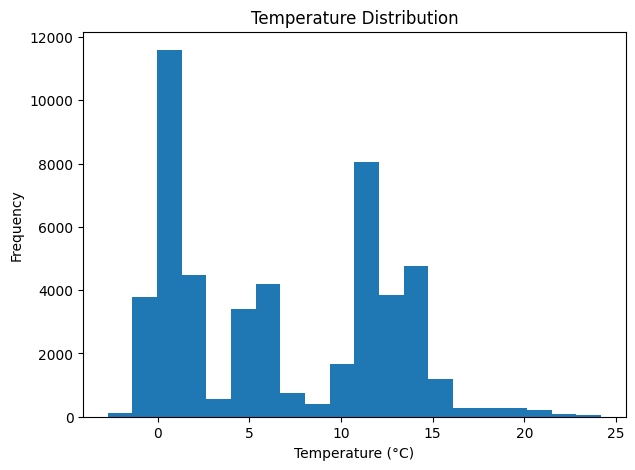

In [7]:
# Temperature Distribution
plt.figure(figsize=(7,5))

plt.hist(data["temperature_c"], bins=20)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

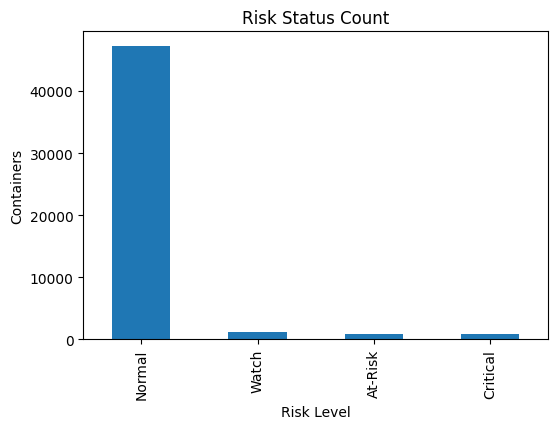

In [9]:
# Visualization 2
# Risk Status
risk = data["risk_status"].value_counts()

plt.figure(figsize=(6,4))

risk.plot(kind="bar")

plt.title("Risk Status Count")
plt.xlabel("Risk Level")
plt.ylabel("Containers")

plt.show()


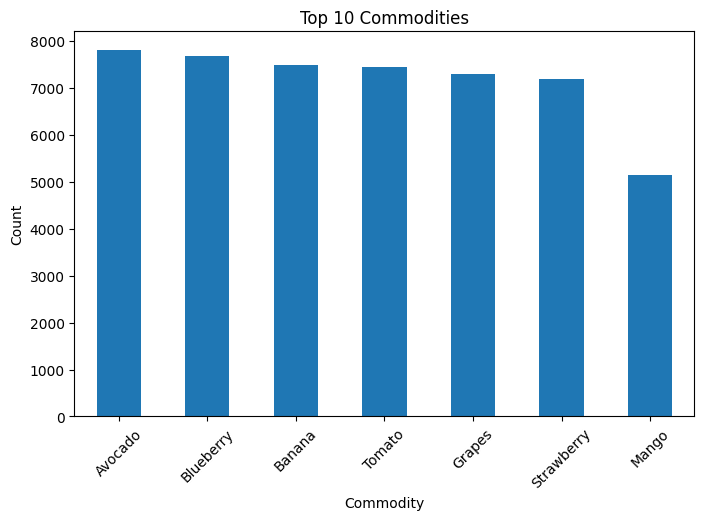

In [10]:
# Visualization 3
# Top Commodities
commodity = data["commodity"].value_counts().head(10)

plt.figure(figsize=(8,5))

commodity.plot(kind="bar")

plt.title("Top 10 Commodities")
plt.xlabel("Commodity")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

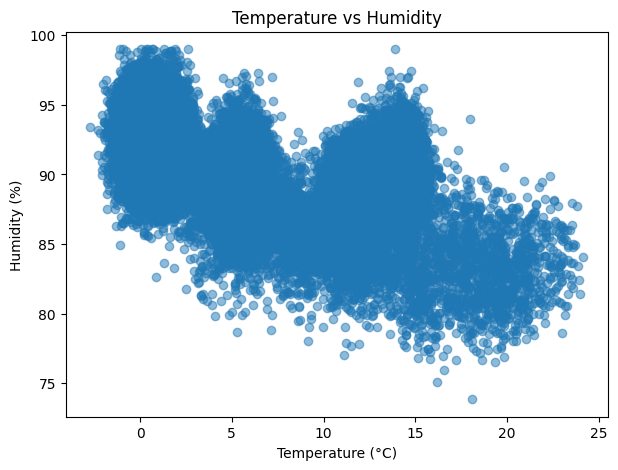

In [11]:
# Visualization 4
# Temperature vs Humidity
plt.figure(figsize=(7,5))

plt.scatter(
    data["temperature_c"],
    data["humidity_pct"],
    alpha=0.5
)

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")

plt.show()

In [12]:
# Export Clean Dataset


output_file = "cleaned_atmosync_dataset.csv"

data.to_csv(output_file, index=False)

print("\nCleaned Dataset Saved Successfully!")
print(f"File Name : {output_file}")


Cleaned Dataset Saved Successfully!
File Name : cleaned_atmosync_dataset.csv
